Jupyter Notebook: Análise do Pipeline U-Net (ISIC 2018 Task 1)
Célula 1: Setup e Importações

In [1]:
import os
import json
import yaml
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ================= CONFIGURAÇÃO DE CAMINHOS =================
# Defina se está no servidor ou na máquina local
unb_server = True

if unb_server:
    BASE_DIR = "/home/antoniovinicius/projects/sandbox_unet"
else:
    BASE_DIR = "/home/avmoura_linux/Documents/unb/sandbox_unet"

LOG_DIR = Path(f"{BASE_DIR}/logs/pipeline_unet_v4")

# Caminhos exatos gerados pelos nossos scripts
CONFIG = {
    # Phase 1: Baseline
    "p1_csv": LOG_DIR / "phase1_baseline" / "unet_baseline" / "results.csv",
    
    # Phase 2: HPO
    "p2_yaml": LOG_DIR / "hpo" / "hpo_v3" / "tune_isic_2018_task_1_unet" / "best_hyperparameters.yaml",
    
    # Phase 3: Optimized
    "p3_csv": LOG_DIR / "phase3_optimized" / "unet_optimized" / "results.csv",
    "p3_args": LOG_DIR / "phase3_optimized" / "unet_optimized" / "args.yaml",
    
    # Phase 4: CV Folds
    "cv_dir": LOG_DIR / "cv" / "cv_v1" / "unet_cv_isic_2018",
    
    # Summaries
    "summary_baseline_json": LOG_DIR / "pipeline_summary" / "baseline_metrics.json",
    "summary_cv_json": LOG_DIR / "pipeline_summary" / "cv_consolidated.json",
    "summary_cv_csv": LOG_DIR / "pipeline_summary" / "cv_consolidated.csv"
}

# Verificação rápida de arquivos
print("=== Verificação de Artefatos ===")
for name, path in CONFIG.items():
    if isinstance(path, Path) and path.suffix in ['.csv', '.json', '.yaml']:
        print(f"[{'OK' if path.exists() else 'FALTA'}] {name}: {path.name}")

=== Verificação de Artefatos ===
[OK] p1_csv: results.csv
[OK] p2_yaml: best_hyperparameters.yaml
[OK] p3_csv: results.csv
[OK] p3_args: args.yaml
[OK] summary_baseline_json: baseline_metrics.json
[OK] summary_cv_json: cv_consolidated.json
[OK] summary_cv_csv: cv_consolidated.csv


Célula 2: Funções de Leitura de Dados

In [2]:
def load_keras_csv(filepath: Path) -> pd.DataFrame:
    """Lê o arquivo results.csv gerado pelo Keras."""
    if not filepath.exists():
        print(f"Arquivo não encontrado: {filepath}")
        return pd.DataFrame()
    return pd.read_csv(filepath)

# Carregando as métricas de Treino (Phase 1 e Phase 3)
df_p1 = load_keras_csv(CONFIG["p1_csv"])
df_p3 = load_keras_csv(CONFIG["p3_csv"])

print(f"Épocas treinadas (Phase 1 - Baseline): {len(df_p1) if not df_p1.empty else 0}")
print(f"Épocas treinadas (Phase 3 - Otimizado): {len(df_p3) if not df_p3.empty else 0}")

Épocas treinadas (Phase 1 - Baseline): 65
Épocas treinadas (Phase 3 - Otimizado): 120


Célula 3: Análise de Hiperparâmetros (Phase 2)

In [3]:
if CONFIG["p2_yaml"].exists():
    with open(CONFIG["p2_yaml"], 'r') as f:
        best_hp = yaml.safe_load(f)
    print("=== Melhores Hiperparâmetros (Optuna) ===")
    print(json.dumps(best_hp, indent=2))
else:
    print("Arquivo best_hyperparameters.yaml não encontrado.")

=== Melhores Hiperparâmetros (Optuna) ===
{
  "activation": "relu",
  "dropout": 0.2959324976396196,
  "loss_type": "bce_dice",
  "lr0": 0.0002616697456085449,
  "n_filters": 32,
  "optimizer": "Adam",
  "weight_decay": 3.0473936177363887e-06
}


Célula 4: Curvas de Aprendizado - Baseline vs Otimizado (Loss e IoU)

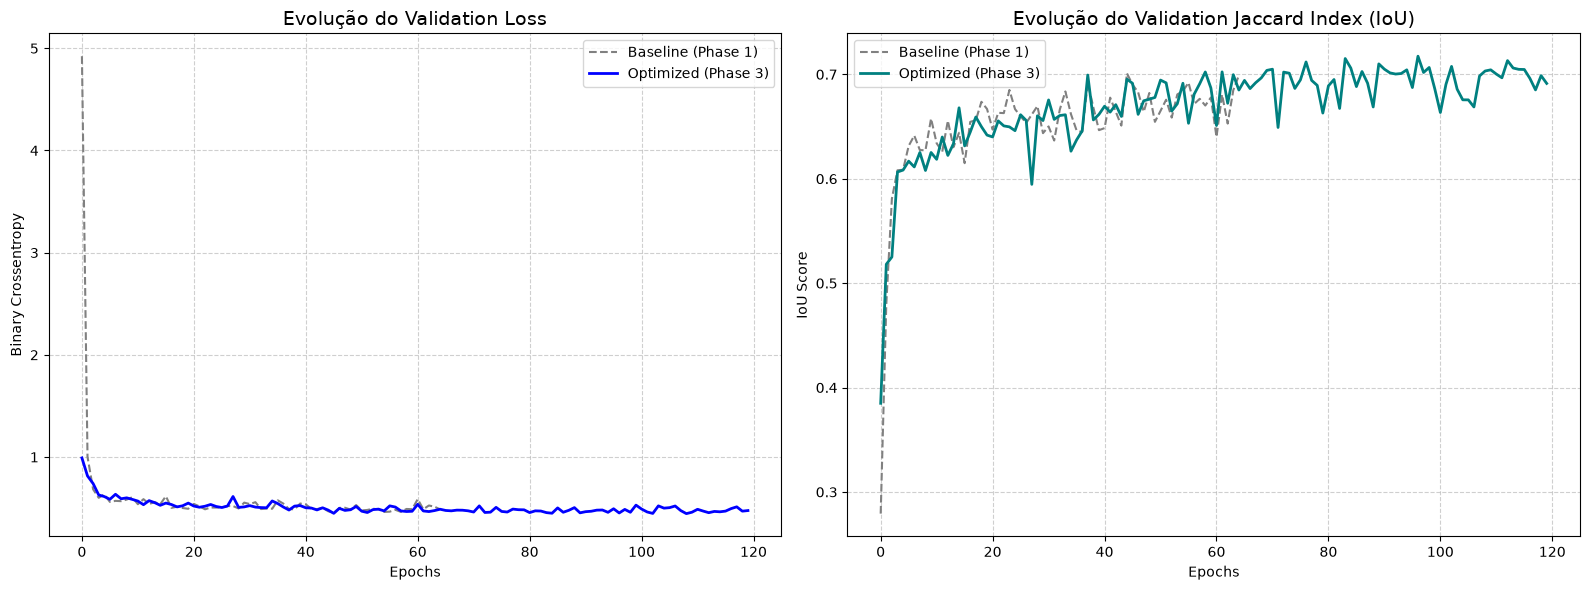

In [4]:
if not df_p1.empty and not df_p3.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Gráfico 1: Evolução da Val_Loss
    axes[0].plot(df_p1['epoch'], df_p1['val_loss'], label='Baseline (Phase 1)', color='gray', linestyle='--')
    axes[0].plot(df_p3['epoch'], df_p3['val_loss'], label='Optimized (Phase 3)', color='blue', linewidth=2)
    axes[0].set_title("Evolução do Validation Loss", fontsize=14)
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("Binary Crossentropy")
    axes[0].grid(True, linestyle="--", alpha=0.6)
    axes[0].legend()

    # Gráfico 2: Evolução do Jaccard Index (IoU)
    # Procuramos as colunas com 'val_custom_iou' ou equivalente
    iou_col = [c for c in df_p1.columns if 'val_' in c and 'iou' in c.lower()][0]
    
    axes[1].plot(df_p1['epoch'], df_p1[iou_col], label='Baseline (Phase 1)', color='gray', linestyle='--')
    axes[1].plot(df_p3['epoch'], df_p3[iou_col], label='Optimized (Phase 3)', color='teal', linewidth=2)
    axes[1].set_title("Evolução do Validation Jaccard Index (IoU)", fontsize=14)
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("IoU Score")
    axes[1].grid(True, linestyle="--", alpha=0.6)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

Célula 5: Detecção de Overfitting (Treino vs Validação - Fase 3)

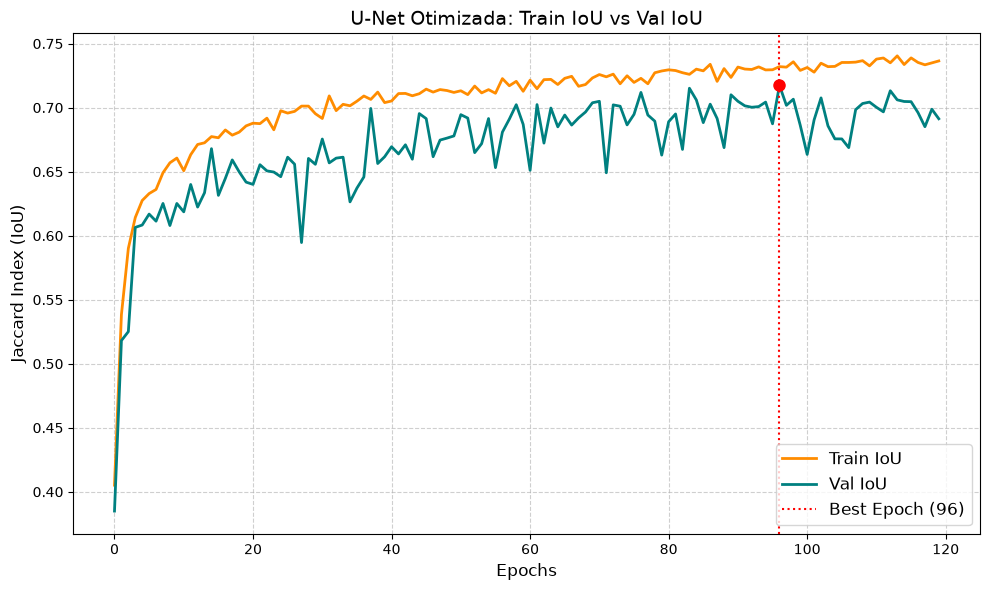

In [5]:
if not df_p3.empty:
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # Identificar colunas corretas
    train_iou_col = [c for c in df_p3.columns if 'iou' in c.lower() and 'val_' not in c][0]
    val_iou_col = [c for c in df_p3.columns if 'val_' in c and 'iou' in c.lower()][0]

    ax1.plot(df_p3['epoch'], df_p3[train_iou_col], label='Train IoU', color='darkorange', linewidth=2)
    ax1.plot(df_p3['epoch'], df_p3[val_iou_col], label='Val IoU', color='teal', linewidth=2)
    
    # Marcar a melhor época
    best_epoch = df_p3[val_iou_col].idxmax()
    best_val_score = df_p3.loc[best_epoch, val_iou_col]
    
    ax1.axvline(x=best_epoch, color='red', linestyle=':', label=f'Best Epoch ({best_epoch})')
    ax1.plot(best_epoch, best_val_score, marker='o', color='red', markersize=8)
    
    ax1.set_title("U-Net Otimizada: Train IoU vs Val IoU", fontsize=14)
    ax1.set_xlabel("Epochs", fontsize=12)
    ax1.set_ylabel("Jaccard Index (IoU)", fontsize=12)
    ax1.grid(True, linestyle="--", alpha=0.6)
    ax1.legend(loc='lower right', fontsize=12)
    
    plt.tight_layout()
    plt.show()

Célula 6: Resultados Consolidados do Cross-Validation (Phase 4)

In [6]:
# Analisar resultados consolidados do CV se a Fase 4 já tiver concluído
if CONFIG["summary_cv_json"].exists():
    with open(CONFIG["summary_cv_json"], 'r') as f:
        cv_results = json.load(f)
        
    print("=== Resultados Consolidados: 5-Fold Cross-Validation ===")
    
    # Extrair e formatar as métricas principais
    summary = cv_results.get("summary", {})
    
    val_iou_mean = summary.get('val_iou', {}).get('mean', 0)
    val_iou_std = summary.get('val_iou', {}).get('std', 0)
    
    val_dice_mean = summary.get('val_dice', {}).get('mean', 0)
    val_dice_std = summary.get('val_dice', {}).get('std', 0)
    
    print(f"Jaccard Index (IoU) Médio: {val_iou_mean:.4f} ± {val_iou_std:.4f}")
    print(f"Dice Coefficient (DSC) Médio: {val_dice_mean:.4f} ± {val_dice_std:.4f}")
    
    # Criar um DataFrame para exibir os resultados por Fold
    folds_data = cv_results.get("per_fold", [])
    if folds_data:
        df_folds = pd.DataFrame(folds_data)
        # Selecionar e renomear colunas para exibição limpa
        cols_to_show = ['fold', 'best_epoch', 'val_iou', 'val_dice', 'train_iou']
        if all(c in df_folds.columns for c in cols_to_show):
            df_folds_display = df_folds[cols_to_show].copy()
            df_folds_display.columns = ['Fold', 'Best Epoch', 'Val IoU', 'Val Dice', 'Train IoU']
            display(df_folds_display)
else:
    print("Os resultados consolidados do Cross-Validation ainda não foram gerados (Fase 4 em andamento).")

=== Resultados Consolidados: 5-Fold Cross-Validation ===
Jaccard Index (IoU) Médio: 0.7227 ± 0.0062
Dice Coefficient (DSC) Médio: 0.8387 ± 0.0042


,Fold,Best Epoch,Val IoU,Val Dice,Train IoU
0,0,89.0,0.718041,0.835585,0.736278
1,1,63.0,0.716440,0.834226,0.719825
2,2,112.0,0.727119,0.841500,0.739929
3,3,104.0,0.732788,0.845553,0.734960
4,4,101.0,0.719193,0.836420,0.734895


Célula 7: Carregamento do Modelo e Dados de Validação

In [7]:
import random
import yaml
import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, Conv2DTranspose, concatenate, Dropout
from tensorflow.keras.models import Model

# 1. Funções de construção da U-Net (Idênticas às do nosso script de treino)
def conv2d_block(input_tensor, n_filters, kernel_size=3, batchnorm=True):
    x = Conv2D(filters=n_filters, kernel_size=(kernel_size, kernel_size), kernel_initializer="he_normal", padding="same")(input_tensor)
    if batchnorm: x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Conv2D(filters=n_filters, kernel_size=(kernel_size, kernel_size), kernel_initializer="he_normal", padding="same")(x)
    if batchnorm: x = BatchNormalization()(x)
    x = Activation("relu")(x)
    return x

def get_unet(input_img, n_filters, dropout, batchnorm):
    c1 = conv2d_block(input_img, n_filters=n_filters*1, batchnorm=batchnorm)
    p1 = Dropout(dropout)(MaxPooling2D((2, 2))(c1))
    c2 = conv2d_block(p1, n_filters=n_filters*2, batchnorm=batchnorm)
    p2 = Dropout(dropout)(MaxPooling2D((2, 2))(c2))
    c3 = conv2d_block(p2, n_filters=n_filters*4, batchnorm=batchnorm)
    p3 = Dropout(dropout)(MaxPooling2D((2, 2))(c3))
    c4 = conv2d_block(p3, n_filters=n_filters*8, batchnorm=batchnorm)
    p4 = Dropout(dropout)(MaxPooling2D(pool_size=(2, 2))(c4))
    c5 = conv2d_block(p4, n_filters=n_filters*16, batchnorm=batchnorm)
    u6 = Conv2DTranspose(n_filters*8, (3, 3), strides=(2, 2), padding='same')(c5)
    c6 = conv2d_block(Dropout(dropout)(concatenate([u6, c4])), n_filters=n_filters*8, batchnorm=batchnorm)
    u7 = Conv2DTranspose(n_filters*4, (3, 3), strides=(2, 2), padding='same')(c6)
    c7 = conv2d_block(Dropout(dropout)(concatenate([u7, c3])), n_filters=n_filters*4, batchnorm=batchnorm)
    u8 = Conv2DTranspose(n_filters*2, (3, 3), strides=(2, 2), padding='same')(c7)
    c8 = conv2d_block(Dropout(dropout)(concatenate([u8, c2])), n_filters=n_filters*2, batchnorm=batchnorm)
    u9 = Conv2DTranspose(n_filters*1, (3, 3), strides=(2, 2), padding='same')(c8)
    c9 = conv2d_block(Dropout(dropout)(concatenate([u9, c1], axis=3)), n_filters=n_filters*1, batchnorm=batchnorm)
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)
    return Model(inputs=[input_img], outputs=[outputs])

# 2. Carregar os hiperparâmetros otimizados (para saber a estrutura correta)
with open(CONFIG["p2_yaml"], 'r') as f:
    best_hp = yaml.safe_load(f)

# 3. Construir a arquitetura e carregar apenas os pesos (evita erro do load_model)
print("Construindo a arquitetura U-Net otimizada...")
input_img = Input((256, 256, 3))
model_unet = get_unet(
    input_img, 
    n_filters=best_hp.get("n_filters", 16), 
    dropout=best_hp.get("dropout", 0.1), 
    batchnorm=best_hp.get("batchnorm", True)
)

best_model_path = LOG_DIR / "phase3_optimized" / "unet_optimized" / "weights" / "best_model.h5"
print(f"Carregando pesos de: {best_model_path.name}...")

# O load_weights ignora a configuração das camadas e injeta apenas as matrizes matemáticas
model_unet.load_weights(best_model_path)

# 4. Carregar os dados de validação diretamente dos .npy
val_img_path = Path(BASE_DIR) / "datasets/isic_2018_task1_numpy/ISIC2018_Task1-2_Validation_Input/ISIC2018_Task1-2_Validation_Input.npy"
val_gt_path = Path(BASE_DIR) / "datasets/isic_2018_task1_numpy/ISIC2018_Task1_Validation_GroundTruth/ISIC2018_Task1_Validation_GroundTruth.npy"

X_val = np.load(val_img_path)
y_val = np.load(val_gt_path)

print(f"Dados de validação carregados! Imagens: {X_val.shape}, Máscaras: {y_val.shape}")

I0000 00:00:1790595202.697040 2907779 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790595202.754838 2907779 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790595204.160795 2907779 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Construindo a arquitetura U-Net otimizada...


I0000 00:00:1790595204.807370 2907779 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11148 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:17:00.0, compute capability: 7.0
I0000 00:00:1790595204.807972 2907779 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13350 MB memory:  -> device: 1, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:65:00.0, compute capability: 7.0


Carregando pesos de: best_model.h5...
Dados de validação carregados! Imagens: (100, 256, 256, 3), Máscaras: (100, 256, 256, 1)


Célula 8: Inferência e Plotagem Qualitativa

Avaliando a imagem do índice: 85


I0000 00:00:1790595207.445216 2909937 service.cc:153] XLA service 0x7a1398040e00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790595207.445255 2909937 service.cc:161]   StreamExecutor [0]: Tesla V100S-PCIE-32GB, Compute Capability 7.0 (Driver: 13.0.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1790595207.445269 2909937 service.cc:161]   StreamExecutor [1]: Tesla V100S-PCIE-32GB, Compute Capability 7.0 (Driver: 13.0.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1790595207.502730 2909937 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


I0000 00:00:1790595207.807513 2909937 cuda_dnn.cc:461] Loaded cuDNN version 91002
E0000 00:00:1790595212.513881 2909937 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1790595215.182149 2909937 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


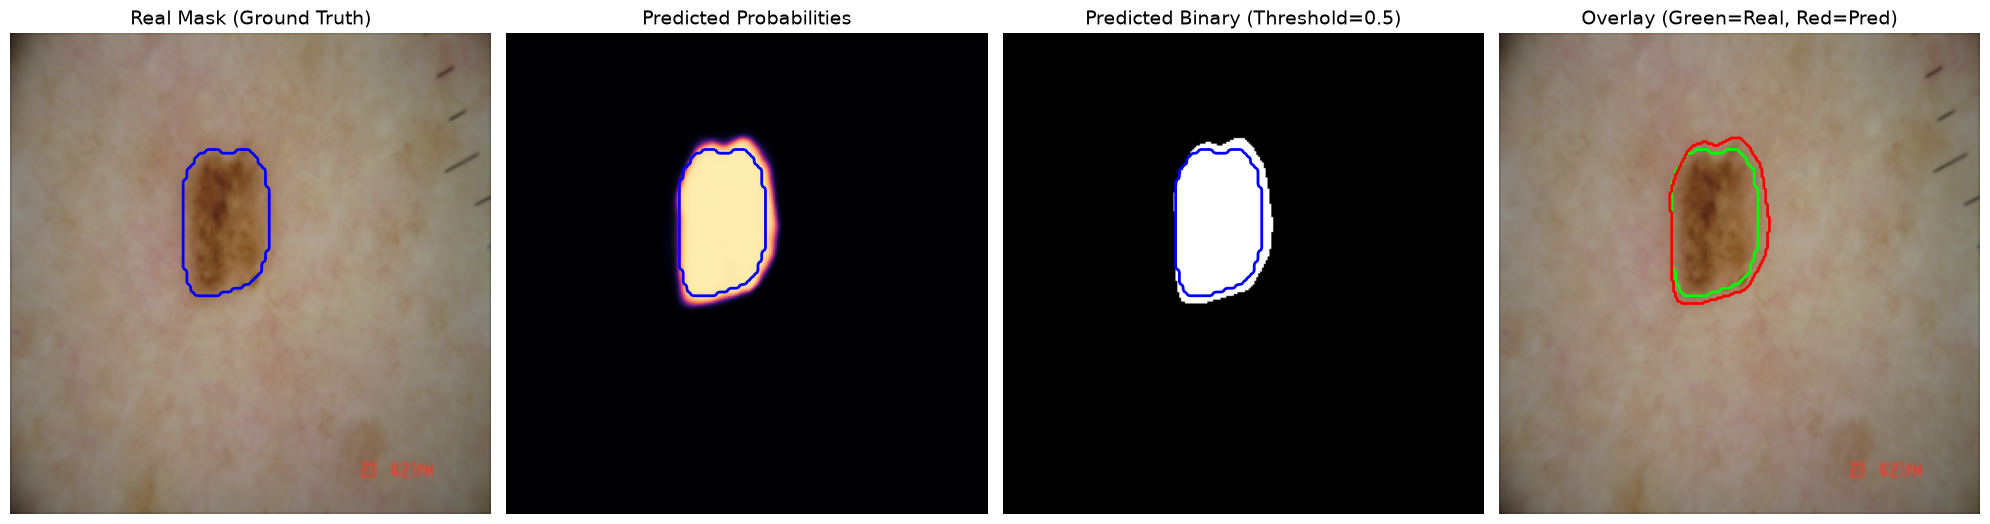

In [8]:
def plot_unet_prediction(X, y, model, ix=None):
    # Seleciona uma imagem aleatória se o índice não for fornecido
    if ix is None:
        ix = random.randint(0, len(X) - 1)
        
    print(f"Avaliando a imagem do índice: {ix}")
    
    img = X[ix]
    gt_mask = y[ix]
    
    # Adicionar a dimensão do batch para a predição (1, H, W, C)
    img_tensor = np.expand_dims(img, axis=0)
    
    # Inferência
    pred_prob = model.predict(img_tensor, verbose=0)[0]
    
    # Binarização com threshold de 0.5 (ideal para saída Sigmoid)
    pred_binary = (pred_prob > 0.5).astype(np.uint8)

    # Plotagem
    fig, ax = plt.subplots(1, 4, figsize=(20, 6))

    # 1. Imagem Original + GT
    ax[0].imshow(img)
    ax[0].contour(gt_mask.squeeze(), colors='blue', levels=[0.5], linewidths=2)
    ax[0].set_title('Real Mask (Ground Truth)', fontsize=14)
    ax[0].axis('off')

    # 2. Probabilidades Contínuas Preditas
    # O colormap 'magma' ou 'jet' é ótimo para visualizar a incerteza da rede nas bordas
    ax[1].imshow(pred_prob.squeeze(), vmin=0, vmax=1, cmap='magma')
    ax[1].contour(gt_mask.squeeze(), colors='blue', levels=[0.5], linewidths=2)
    ax[1].set_title('Predicted Probabilities', fontsize=14)
    ax[1].axis('off')

    # 3. Predição Binarizada
    ax[2].imshow(pred_binary.squeeze(), vmin=0, vmax=1, cmap='gray')
    ax[2].contour(gt_mask.squeeze(), colors='blue', levels=[0.5], linewidths=2)
    ax[2].set_title('Predicted Binary (Threshold=0.5)', fontsize=14)
    ax[2].axis('off')

    # 4. Sobreposição (Overlay GT vs Pred)
    ax[3].imshow(img)
    # Verde para o Real, Vermelho para o Predito
    ax[3].contour(gt_mask.squeeze(), colors='#00FF00', levels=[0.5], linewidths=2)
    ax[3].contour(pred_binary.squeeze(), colors='red', levels=[0.5], linewidths=2)
    ax[3].set_title('Overlay (Green=Real, Red=Pred)', fontsize=14)
    ax[3].axis('off')

    plt.tight_layout()
    plt.show()

# Executar a função
plot_unet_prediction(X_val, y_val, model_unet)

Célula 9: Tabela Final do 5-Fold Cross-Validation

In [9]:
import json
import pandas as pd
from IPython.display import display

# Carregar o JSON consolidado do CV gerado pelo pipeline
cv_json_path = LOG_DIR / "pipeline_summary" / "cv_consolidated.json"

if cv_json_path.exists():
    with open(cv_json_path, 'r') as f:
        cv_data = json.load(f)

    print("=== Resultados: 5-Fold Cross-Validation (U-Net) ===")
    
    # Criar e formatar DataFrame com os resultados por fold
    df_cv = pd.DataFrame(cv_data['per_fold'])
    cols_to_show = ['fold', 'best_epoch', 'train_loss', 'val_loss', 'train_iou', 'val_iou', 'train_dice', 'val_dice']
    df_cv_display = df_cv[cols_to_show].copy()
    
    # Renomear colunas para apresentação acadêmica
    df_cv_display.columns = ['Fold', 'Best Epoch', 'Train Loss', 'Val Loss', 'Train IoU', 'Val IoU', 'Train Dice', 'Val Dice']
    display(df_cv_display)
    
    # Exibir o Resumo Estatístico Final
    summary = cv_data['summary']
    print("\n=== Resumo Estatístico Global (Média ± Desvio Padrão) ===")
    print(f"Validation Jaccard Index (IoU) : {summary['val_iou']['mean']:.4f} ± {summary['val_iou']['std']:.4f}")
    print(f"Validation Dice Coefficient    : {summary['val_dice']['mean']:.4f} ± {summary['val_dice']['std']:.4f}")
    print(f"Época Ideal Média (Paciência)  : {summary['best_epoch']['mean']:.1f} ± {summary['best_epoch']['std']:.1f}")
else:
    print("Arquivo cv_consolidated.json não encontrado.")

=== Resultados: 5-Fold Cross-Validation (U-Net) ===


,Fold,Best Epoch,Train Loss,Val Loss,Train IoU,Val IoU,Train Dice,Val Dice
0,0,89.0,0.358638,0.388643,0.736278,0.718041,0.847312,0.835585
1,1,63.0,0.377316,0.396821,0.719825,0.716440,0.836268,0.834226
2,2,112.0,0.352361,0.364371,0.739929,0.727119,0.849992,0.841500
3,3,104.0,0.360256,0.359404,0.734960,0.732788,0.846549,0.845553
4,4,101.0,0.360416,0.394591,0.734895,0.719193,0.846512,0.836420



=== Resumo Estatístico Global (Média ± Desvio Padrão) ===
Validation Jaccard Index (IoU) : 0.7227 ± 0.0062
Validation Dice Coefficient    : 0.8387 ± 0.0042
Época Ideal Média (Paciência)  : 93.8 ± 17.1


Célula 10: Boxplot de Estabilidade da Validação Cruzada

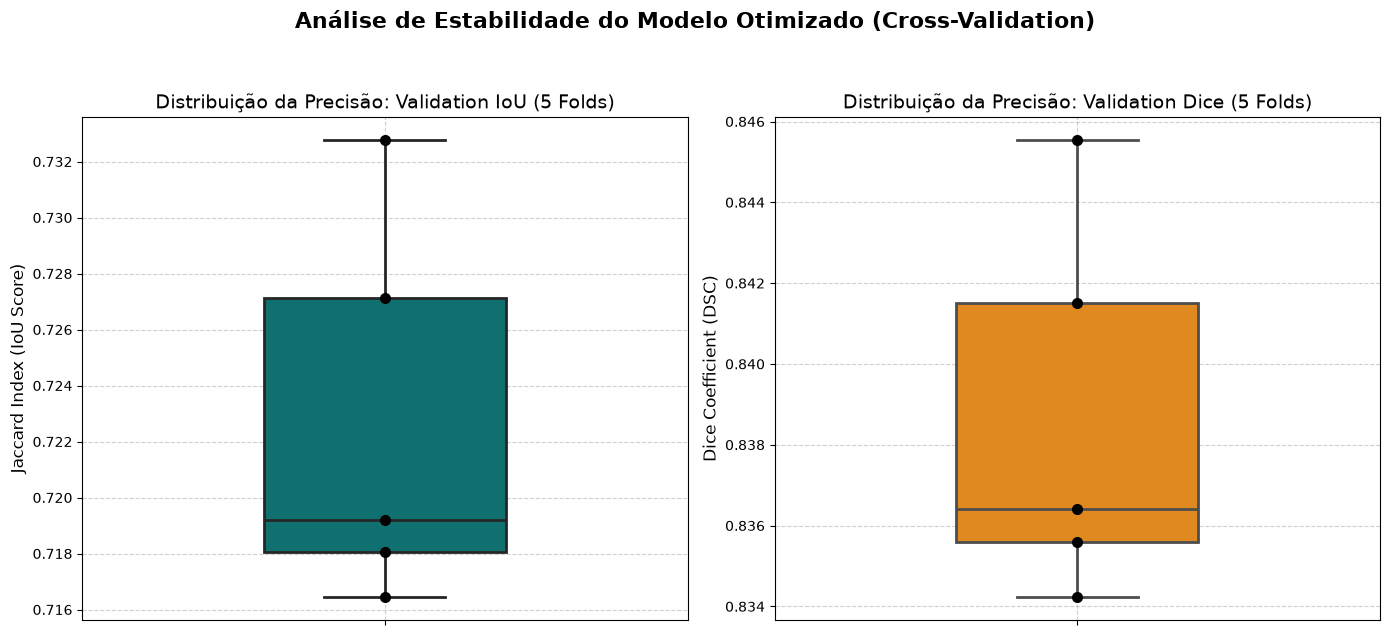

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

if 'df_cv' in locals() and not df_cv.empty:
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    # Boxplot para IoU
    sns.boxplot(y=df_cv['val_iou'], ax=ax[0], color='teal', width=0.4, linewidth=2)
    sns.swarmplot(y=df_cv['val_iou'], ax=ax[0], color='black', size=8)
    ax[0].set_title('Distribuição da Precisão: Validation IoU (5 Folds)', fontsize=14)
    ax[0].set_ylabel('Jaccard Index (IoU Score)', fontsize=12)
    ax[0].grid(True, linestyle="--", alpha=0.6)

    # Boxplot para Dice
    sns.boxplot(y=df_cv['val_dice'], ax=ax[1], color='darkorange', width=0.4, linewidth=2)
    sns.swarmplot(y=df_cv['val_dice'], ax=ax[1], color='black', size=8)
    ax[1].set_title('Distribuição da Precisão: Validation Dice (5 Folds)', fontsize=14)
    ax[1].set_ylabel('Dice Coefficient (DSC)', fontsize=12)
    ax[1].grid(True, linestyle="--", alpha=0.6)

    plt.suptitle("Análise de Estabilidade do Modelo Otimizado (Cross-Validation)", fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

Célula 11: Gráfico Comparativo do Estudo (Baseline vs Otimizado vs CV)

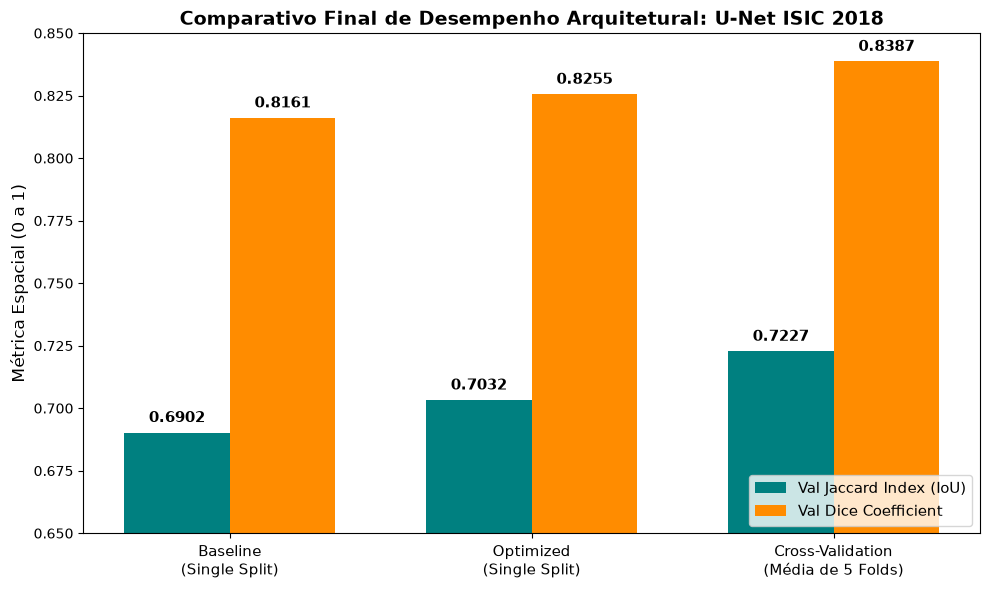

In [11]:
# Carregar dados do Baseline e Fase 3 para comparação final
base_json_path = LOG_DIR / "pipeline_summary" / "baseline_metrics.json"
opt_json_path = LOG_DIR / "pipeline_summary" / "optimized_metrics.json"

if base_json_path.exists() and opt_json_path.exists() and 'cv_data' in locals():
    with open(base_json_path, 'r') as f:
        base_data = json.load(f)['models'][0]
    with open(opt_json_path, 'r') as f:
        opt_data = json.load(f)['models'][0]

    # Estruturar os dados para o gráfico de barras
    labels = ['Baseline\n(Single Split)', 'Optimized\n(Single Split)', 'Cross-Validation\n(Média de 5 Folds)']
    iou_scores = [base_data['val_iou'], opt_data['val_iou'], cv_data['summary']['val_iou']['mean']]
    dice_scores = [base_data['val_dice'], opt_data['val_dice'], cv_data['summary']['val_dice']['mean']]

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, iou_scores, width, label='Val Jaccard Index (IoU)', color='teal')
    rects2 = ax.bar(x + width/2, dice_scores, width, label='Val Dice Coefficient', color='darkorange')

    # Configuração do gráfico
    ax.set_ylabel('Métrica Espacial (0 a 1)', fontsize=12)
    ax.set_title('Comparativo Final de Desempenho Arquitetural: U-Net ISIC 2018', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.legend(loc='lower right', fontsize=11)
    
    # Zoom no eixo Y para evidenciar a evolução acadêmica
    ax.set_ylim(0.65, 0.85) 

    # Anotações matemáticas no topo de cada barra
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.4f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 5),  # Deslocamento vertical
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=11, fontweight='bold')

    autolabel(rects1)
    autolabel(rects2)

    plt.tight_layout()
    plt.show()
else:
    print("Arquivos JSON necessários para a comparação final não encontrados.")